In [1]:
from src.baseline.qwen3 import init_model
from src.utils import build_messages, read_json_file
from pathlib import Path
from typing import List, Tuple, Dict, Any, Optional
import statistics
import json
tokenizer, model = init_model("Qwen/Qwen3-0.6B")

d:\GitHub\text2cypher_distillation_draft\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 311/311 [00:03<00:00, 103.07it/s]
The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Some parameters are on the meta device because they were offloaded to the cpu and disk.


In [2]:
benchmark = "Neo4j_Text2Cypher"
# benchmark = "Cypherbench"
# benchmark = "Mind_the_query"
# raw_test_data = read_json_file(Path("benchmarks") / benchmark / "test.json")
raw_train_data = read_json_file(Path("benchmarks") / benchmark / "train.json")
# raw_train_data = read_json_file(Path("benchmarks") / benchmark / "train_val.json")

In [3]:
with open("prompts/generator/system_prompt.txt", "r", encoding="utf-8") as f:
    SYSTEM_PROMPT = f.read()

with open("prompts/generator/user_prompt.txt", "r", encoding="utf-8") as f:
    USER_PROMPT = f.read()

In [4]:
def load_schema_for_graph(benchmark: str, graph_name: str) -> Optional[str]:
    if benchmark == "Cypherbench":
        schema_path = Path("benchmarks") / benchmark / "graphs" / "schemas" / f"{graph_name}_schema.json"
    elif benchmark == "Mind_the_query":
        schema_path = Path("benchmarks") / benchmark / "graphs" / "schemas" / f"{graph_name}.json"
    else:
        return None

    if not schema_path.exists():
        print(f"Schema file not found for graph={graph_name}: {schema_path}")
        return None

    schema = read_json_file(schema_path)
    return json.dumps(schema, indent=4, ensure_ascii=False)

In [5]:
def get_prompt_text(tokenizer, question: str, schema: str, enable_thinking: bool = False) -> str:
    messages = build_messages(question, schema)
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=enable_thinking,
    )
    return text

def token_length(tokenizer, text: str, model_device=None) -> int:
    inputs = tokenizer(text, return_tensors="pt")
    if model_device is not None:
        inputs = inputs.to(model_device)
    return inputs["input_ids"].shape[-1]

def summarize_lengths(lengths: List[int]) -> Dict[str, Any]:
    if not lengths:
        return {}

    lengths_sorted = sorted(lengths)
    n = len(lengths_sorted)

    def percentile(p: float) -> float:
        if n == 1:
            return lengths_sorted[0]
        idx = (n - 1) * p
        low = int(idx)
        high = min(low + 1, n - 1)
        frac = idx - low
        return lengths_sorted[low] * (1 - frac) + lengths_sorted[high] * frac

    return {
        "count": n,
        "min": min(lengths_sorted),
        "max": max(lengths_sorted),
        "mean": sum(lengths_sorted) / n,
        "median": statistics.median(lengths_sorted),
        "p50": percentile(0.50),
        "p90": percentile(0.90),
        "p95": percentile(0.95),
        "p99": percentile(0.99),
    }

In [6]:
from tqdm.auto import tqdm
def analyze_dataset_token_lengths(
    dataset: List[Dict[str, Any]],
    tokenizer,
    enable_thinking: bool = False,
):
    prompt_lengths = []
    prompt_plus_gold_lengths = []

    results = []

    if benchmark != "Mind_the_query":
        question_key = "nl_question"
    else:
        question_key = "question"


    for i, item in tqdm(enumerate(dataset), total=len(dataset)):
        question = item[question_key]
        if benchmark == "Neo4j_Text2Cypher":
            schema = item["schema"]
        else:
            graph = item["graph"]
            schema = load_schema_for_graph(benchmark, graph)
        gold_cypher = item["gold_cypher"]

        prompt_text = get_prompt_text(
            tokenizer=tokenizer,
            question=question,
            schema=schema,
            enable_thinking=enable_thinking,
        )

        # prompt only
        prompt_len = token_length(tokenizer, prompt_text)

        # prompt + gold cypher
        full_text = prompt_text + gold_cypher
        full_len = token_length(tokenizer, full_text)

        prompt_lengths.append(prompt_len)
        prompt_plus_gold_lengths.append(full_len)

        results.append({
            "idx": i,
            "question": question,
            "prompt_len": prompt_len,
            "prompt_plus_gold_len": full_len,
            "gold_cypher_len_only": full_len - prompt_len,
        })

    summary = {
        "prompt_only": summarize_lengths(prompt_lengths),
        "prompt_plus_gold": summarize_lengths(prompt_plus_gold_lengths),
    }

    return results, summary

In [7]:
# results, summary = analyze_dataset_token_lengths(raw_test_data, tokenizer, enable_thinking=False)
results, summary = analyze_dataset_token_lengths(raw_train_data, tokenizer, enable_thinking=False)

100%|██████████| 39554/39554 [03:25<00:00, 192.31it/s]


In [8]:
summary

{'prompt_only': {'count': 39554,
  'min': 206,
  'max': 3156,
  'mean': 875.5256105577186,
  'median': 683.0,
  'p50': 683.0,
  'p90': 1561.0,
  'p95': 2953.0,
  'p99': 2961.0},
 'prompt_plus_gold': {'count': 39554,
  'min': 216,
  'max': 3209,
  'mean': 918.588107397482,
  'median': 722.0,
  'p50': 722.0,
  'p90': 1609.0,
  'p95': 2981.0,
  'p99': 3010.0}}

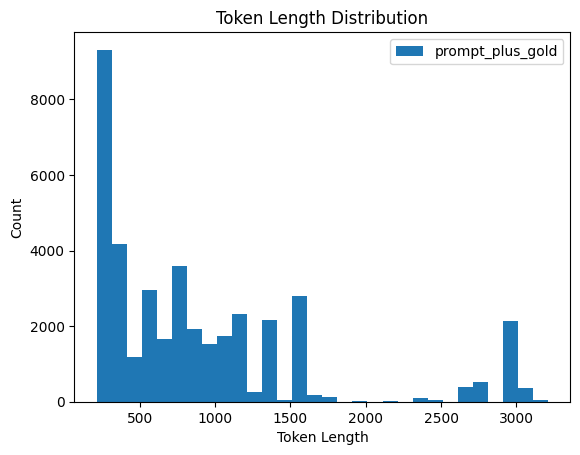

In [9]:
import matplotlib.pyplot as plt

# prompt_lens = [x["prompt_len"] for x in results]
full_lens = [x["prompt_plus_gold_len"] for x in results]

plt.figure()

# plt.hist(prompt_lens, bins=30, alpha=0.6, label="prompt_only")
plt.hist(full_lens, bins=30, alpha=1, label="prompt_plus_gold")

plt.xlabel("Token Length")
plt.ylabel("Count")
plt.title("Token Length Distribution")
plt.legend()

plt.show()